In [1]:
# 1. Pobranie danych

import yfinance as yf
import pandas as pd
from pathlib import Path

# =========================
# Parametry
# =========================
TICKER = "^GSPC"
START_DATE = "1900-01-01"
END_DATE = None
INTERVAL = "1d"

DATA_DIR = Path("data/market")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_NAME = f"{TICKER.replace('^','')}_{INTERVAL}"
PARQUET_PATH = DATA_DIR / f"{BASE_NAME}.parquet"
CSV_PATH = DATA_DIR / f"{BASE_NAME}.csv"


def load_or_download_data(
    ticker: str,
    start: str,
    end: str | None,
    interval: str,
    parquet_path: Path,
    csv_path: Path
) -> pd.DataFrame:
    """
    Ładuje dane z dysku jeśli istnieją,
    w przeciwnym razie pobiera je z yfinance i zapisuje.

    Parquet: format roboczy dla projektu
    CSV:     format pomocniczy do wglądu
    """

    if parquet_path.exists():
        print(f"[INFO] Wczytywanie danych z cache: {parquet_path}")
        try:
            df = pd.read_parquet(parquet_path)

            # CSV tylko do wglądu — jeśli nie istnieje, spróbuj go odtworzyć
            if not csv_path.exists():
                try:
                    df.to_csv(csv_path, index=True)
                    print(f"[INFO] (Podgląd) Dane zapisane do CSV: {csv_path}")
                except Exception as e:
                    raise RuntimeError(
                        f"Nie udało się zapisać CSV do {csv_path}"
                    ) from e

            return df
        except Exception as e:
            raise RuntimeError(
                f"Błąd podczas wczytywania danych z {parquet_path}"
            ) from e

    print("[INFO] Brak danych w cache — pobieranie z yfinance...")
    try:
        df = yf.download(
            tickers=ticker,
            start=start,
            end=end,
            interval=interval,
            auto_adjust=False,
            progress=False
        )
    except Exception as e:
        raise RuntimeError("Błąd podczas pobierania danych z yfinance") from e

    if df.empty:
        raise ValueError("Pobrane dane są puste — sprawdź ticker lub zakres dat")

    # Spłaszczenie MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    # Standaryzacja nazw kolumn
    df = df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Adj Close": "adj_close",
        "Volume": "volume"
    })

    df = df.dropna()

    try:
        df.to_parquet(parquet_path)
        print(f"[INFO] Dane zapisane do: {parquet_path}")
    except Exception as e:
        raise RuntimeError(
            f"Nie udało się zapisać danych do {parquet_path}"
        ) from e

    try:
        df.to_csv(csv_path, index=True)
        print(f"[INFO] (Podgląd) Dane zapisane do CSV: {csv_path}")
    except Exception as e:
        raise RuntimeError(
            f"Nie udało się zapisać CSV do {csv_path}"
        ) from e

    return df


# =========================
# Użycie
# =========================
df = load_or_download_data(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    parquet_path=PARQUET_PATH,
    csv_path=CSV_PATH
)

print(df.head())
print(df.tail())
print(df.info())


[INFO] Wczytywanie danych z cache: data/market/GSPC_1d.parquet
            adj_close      close       high        low       open  volume
Date                                                                     
1927-12-30  17.660000  17.660000  17.660000  17.660000  17.660000       0
1928-01-03  17.760000  17.760000  17.760000  17.760000  17.760000       0
1928-01-04  17.719999  17.719999  17.719999  17.719999  17.719999       0
1928-01-05  17.549999  17.549999  17.549999  17.549999  17.549999       0
1928-01-06  17.660000  17.660000  17.660000  17.660000  17.660000       0
              adj_close        close         high          low         open  \
Date                                                                          
2026-01-28  6978.029785  6978.029785  7002.279785  6963.459961  7002.000000   
2026-01-29  6969.009766  6969.009766  6992.839844  6870.799805  6977.740234   
2026-01-30  6939.029785  6939.029785  6964.089844  6893.479980  6947.270020   
2026-02-02  6976.439941 

In [5]:
# Punkt 2: Walidacja surowych danych

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence
import pandas as pd


# =========================
# Wyjątki / wyniki walidacji
# =========================

class ValidationError(ValueError):
    """Błąd walidacji danych surowych."""


@dataclass(frozen=True)
class ValidationIssue:
    validator: str
    check: str
    message: str
    n_bad: int = 0
    csv_path: Optional[Path] = None


# =========================
# Baza dla walidatorów
# =========================

class BaseRawValidator:
    """Interfejs dla pojedynczego walidatora surowych danych."""
    name: str = "BaseRawValidator"

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        raise NotImplementedError

    def _ensure_blacksheep_dir(self, blacksheep_dir: Optional[Path]) -> Path:
        if blacksheep_dir is None:
            raise ValidationError(
                "blacksheep_dir jest wymagany gdy saveBlackSheeps=True."
            )
        blacksheep_dir = Path(blacksheep_dir)
        blacksheep_dir.mkdir(parents=True, exist_ok=True)
        return blacksheep_dir

    def _save_blacksheeps(
        self,
        df_or_subset: pd.DataFrame,
        *,
        blacksheep_dir: Path,
        check: str,
    ) -> Path:
        # Uwaga: nie używam timestampów, żeby wyniki były deterministyczne przy powtarzalnych uruchomieniach.
        # Jeśli wolisz unikalne nazwy, łatwo dopisać suffix.
        safe_check = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in check)
        out_path = blacksheep_dir / f"{self.name}__{safe_check}.csv"
        df_or_subset.to_csv(out_path, index=True)
        return out_path


# =========================================
# Punkt 2: Walidacja surowych danych (cz. 1)
# 1) Indeks i oś czasu
# =========================================

class IndexAndTimeAxisValidator(BaseRawValidator):
    """
    Walidacje dla:
    1) Indeks i oś czasu

    Każdy podpunkt ma osobną metodę.
    """
    name = "IndexAndTimeAxisValidator"

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        # Kolejność ma znaczenie: najpierw typ indeksu, bo pozostałe checki na nim polegają.
        issues += self.check_datetime_index(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)

        # Jeśli indeks nie jest DatetimeIndex, dalsze checki nie mają sensu.
        if issues and any(i.check == "check_datetime_index" for i in issues):
            raise ValidationError(self._format_issues(issues))

        issues += self.check_no_nat_in_index(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_monotonic_increasing(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_unique_index(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_consistent_time_component_daily(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)
        issues += self.check_timezone_consistency(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)

        if issues:
            # W tym projekcie przyjmujemy twarde walidacje na raw.
            raise ValidationError(self._format_issues(issues))

        return issues

    # -------------------------
    # Podpunkt: DatetimeIndex
    # -------------------------

    def check_datetime_index(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        if isinstance(df.index, pd.DatetimeIndex):
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # Nie da się jednoznacznie wskazać "złych rekordów" bez poprawnego indeksu czasu,
            # więc zapisujemy całe df jako blacksheeps.
            csv_path = self._save_blacksheeps(df, blacksheep_dir=out_dir, check="check_datetime_index")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_datetime_index",
                message=f"Index musi być pandas.DatetimeIndex, a jest: {type(df.index).__name__}.",
                n_bad=len(df),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: brak NaT w indeksie
    # -------------------------

    def check_no_nat_in_index(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index  # po check_datetime_index
        nat_mask = idx.isna() # NaT → brakująca data / czas

        if not nat_mask.any():
            return []

        bad_df = df.loc[nat_mask]
        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_no_nat_in_index")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_no_nat_in_index",
                message="Index zawiera NaT (brakujące daty/czasy) – to błąd na surowych danych.",
                n_bad=int(nat_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: monotonicznie rosnący
    # -------------------------

    def check_monotonic_increasing(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index
        if idx.is_monotonic_increasing:
            return []

        # Rekordy "odpowiedzialne" za fail: miejsca, gdzie kolejny timestamp jest mniejszy od poprzedniego.
        # Zaznaczamy oba wiersze: poprzedni i bieżący.
        diffs = idx[1:] < idx[:-1]
        bad_pos = diffs.to_numpy().nonzero()[0] + 1  # pozycje "bieżące"
        bad_pos = sorted(set(bad_pos.tolist() + (bad_pos - 1).tolist()))
        bad_df = df.iloc[bad_pos]

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_monotonic_increasing")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_monotonic_increasing",
                message="Index nie jest monotonicznie rosnący (oś czasu jest 'poszarpana').",
                n_bad=len(bad_df),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: unikalny indeks (brak duplikatów)
    # -------------------------

    def check_unique_index(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index
        dup_mask = idx.duplicated(keep=False)

        if not dup_mask.any():
            return []

        bad_df = df.loc[dup_mask]
        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_unique_index")

        # Dodatkowy kontekst: ile unikalnych duplikowanych timestampów
        n_dup_groups = idx[dup_mask].unique().shape[0]

        return [
            ValidationIssue(
                validator=self.name,
                check="check_unique_index",
                message=f"Index zawiera duplikaty timestampów (liczba grup duplikatów: {n_dup_groups}).",
                n_bad=int(dup_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: "dziwne godziny" dla danych dziennych
    # -------------------------

    def check_consistent_time_component_daily(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        """
        Dla interwału 1d chcemy spójny komponent czasu w znacznikach (np. zawsze 00:00:00),
        bo mieszanie 00:00 i 16:00 potrafi psuć rolling/shift i joiny.

        Heurystyka:
        - bierzemy najczęstszy (mode) komponent czasu i wymagamy, by wszystkie były takie same.
        """
        idx: pd.DatetimeIndex = df.index

        # komponent czasu jako liczba ns od północy
        time_ns = (idx.hour.astype("int64") * 3600
                   + idx.minute.astype("int64") * 60
                   + idx.second.astype("int64")) * 1_000_000_000 + idx.nanosecond.astype("int64")

        # mode:
        vc = pd.Series(time_ns).value_counts(dropna=False)
        mode_time_ns = int(vc.index[0])
        bad_mask = time_ns != mode_time_ns

        if not bool(bad_mask.any()):
            return []

        bad_df = df.loc[bad_mask]

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_consistent_time_component_daily")

        # ładniejszy opis mode (HH:MM:SS)
        mode_sec = mode_time_ns // 1_000_000_000
        hh = mode_sec // 3600
        mm = (mode_sec % 3600) // 60
        ss = mode_sec % 60

        return [
            ValidationIssue(
                validator=self.name,
                check="check_consistent_time_component_daily",
                message=f"Niespójny komponent czasu w indeksie (dla 1d oczekuję stałej godziny; najczęstsza to {hh:02d}:{mm:02d}:{ss:02d}).",
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: spójność TZ (albo brak TZ, albo konsekwentnie jedna)
    # -------------------------

    def check_timezone_consistency(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        idx: pd.DatetimeIndex = df.index

        # W pandas DatetimeIndex ma jedną tz albo None.
        # Ten check łapie przypadki pośrednie (np. index jako object -> już odpadliśmy),
        # oraz wymusza "albo brak TZ, albo jedna" (co i tak trzyma pandas).
        # Dodatkowo: jeżeli tz-aware, to zostawiamy (kontrakt mówi: albo brak TZ, albo konsekwentnie jedna).
        # Jeśli chcesz wymusić tz-naive, to tu zmienimy regułę.
        if idx.tz is None or idx.tz is not None:
            return []

        # Teoretycznie nieosiągalne dla DatetimeIndex, ale zostawiam jako guard.
        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(df, blacksheep_dir=out_dir, check="check_timezone_consistency")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_timezone_consistency",
                message="Niespójna strefa czasowa w indeksie (wymagana jedna TZ albo brak TZ).",
                n_bad=len(df),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Helper do formatowania
    # -------------------------

    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = ["[RAW VALIDATION FAILED] 1) Indeks i oś czasu:"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)

# =========================================
# Punkt 2: Walidacja surowych danych (cz. 2)
# 2) Ciągłość dat (kalendarz sesji)
# =========================================

class SessionCalendarContinuityValidator(BaseRawValidator):
    """
    Walidacje dla:
    2) Ciągłość dat (kalendarz sesji)

    Kontrakt:
    - Poziom A (twardy): każda data w danych MUSI być dniem sesyjnym (NYSE dla ^GSPC).
      Jeśli nie -> ValidationError (+ opcjonalny zapis blacksheeps jako rekordy z błędnych dni).
    - Poziom B (miękki): brakujące sesje są dozwolone (nie imputujemy), ale logujemy WARNING
      (+ opcjonalny zapis listy brakujących sesji do CSV).
    """
    name = "SessionCalendarContinuityValidator"

    def __init__(self, calendar: str = "NYSE"):
        self.calendar = calendar

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        # Własny minimalny kontrakt wejścia (nie zależy od punktu 1 jako klasy)
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValidationError(
                f"{self.name} wymaga DatetimeIndex (otrzymano: {type(df.index).__name__})."
            )

        # A) Twardo: dni spoza kalendarza sesji
        issues += self.check_all_rows_are_session_days(
            df,
            saveBlackSheeps=saveBlackSheeps,
            blacksheep_dir=blacksheep_dir,
        )
        if issues and any(i.check == "check_all_rows_are_session_days" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # B) Miękko: brakujące sesje (warning)
        issues += self.check_missing_sessions(
            df,
            saveBlackSheeps=saveBlackSheeps,
            blacksheep_dir=blacksheep_dir,
        )
        for w in [i for i in issues if i.check == "check_missing_sessions"]:
            extra = f" | blacksheeps: {w.csv_path}" if w.csv_path else ""
            print(f"[RAW VALIDATION WARNING] {self.name}.{w.check}: {w.message} (n_bad={w.n_bad}){extra}")

        return issues

    # -------------------------
    # Poziom A: daty w danych muszą być sesyjne
    # -------------------------

    def check_all_rows_are_session_days(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        sessions = self._get_sessions_for_range(df)

        # Porównujemy po "dniu" (normalize), bo indeks może mieć godzinę.
        data_days = df.index.normalize().unique()
        session_days = sessions.normalize().unique()

        bad_days = data_days.difference(session_days)
        if len(bad_days) == 0:
            return []

        # rekordy odpowiedzialne za fail: wszystkie wiersze z bad_days
        bad_mask = df.index.normalize().isin(bad_days)
        bad_df = df.loc[bad_mask].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df,
                blacksheep_dir=out_dir,
                check="check_all_rows_are_session_days",
            )

        sample = [d.strftime("%Y-%m-%d") for d in pd.to_datetime(bad_days[:5])]
        sample_txt = ", ".join(sample) + (" ..." if len(bad_days) > 5 else "")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_all_rows_are_session_days",
                message=(
                    f"Znaleziono rekordy dla dni nienależących do kalendarza sesji ({self.calendar}). "
                    f"Przykłady dni: {sample_txt}."
                ),
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Poziom B: brakujące sesje (warning)
    # -------------------------

    def check_missing_sessions(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        sessions = self._get_sessions_for_range(df)

        data_days = df.index.normalize().unique()
        session_days = sessions.normalize().unique()

        missing_days = session_days.difference(data_days)
        if len(missing_days) == 0:
            return []

        # zapiszemy listę braków (to nie są "rekordy df", więc robimy osobny DF)
        missing_df = pd.DataFrame({"missing_session_day": pd.to_datetime(missing_days).sort_values()})

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # nadpisujemy _save_blacksheeps? nie, używamy go i zapisujemy z index=True (będzie 0..n-1)
            # bo BaseRawValidator i tak zapisuje index=True — to OK.
            csv_path = self._save_blacksheeps(
                missing_df,
                blacksheep_dir=out_dir,
                check="check_missing_sessions",
            )

        sample = [d.strftime("%Y-%m-%d") for d in pd.to_datetime(missing_days[:5])]
        sample_txt = ", ".join(sample) + (" ..." if len(missing_days) > 5 else "")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_missing_sessions",
                message=(
                    f"W danych brakuje niektórych dni sesyjnych ({self.calendar}). "
                    f"Nie imputujemy (zgodnie z kontraktem). Przykłady braków: {sample_txt}."
                ),
                n_bad=len(missing_days),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Backend kalendarza (exchange_calendars -> fallback pandas_market_calendars)
    # -------------------------

    def _get_sessions_for_range(self, df: pd.DataFrame) -> pd.DatetimeIndex:
        start = df.index.min().normalize()
        end = df.index.max().normalize()

        # 1) exchange_calendars
        try:
            import exchange_calendars as ecals  # type: ignore
            cal_code = "XNYS" if self.calendar.upper() == "NYSE" else self.calendar
            cal = ecals.get_calendar(cal_code)
            sessions = cal.sessions_in_range(start, end)
            if sessions.tz is not None:
                sessions = sessions.tz_convert(None)
            return pd.DatetimeIndex(sessions)
        except Exception:
            pass

        # 2) pandas_market_calendars
        try:
            import pandas_market_calendars as mcal  # type: ignore
            cal = mcal.get_calendar(self.calendar.upper())
            schedule = cal.schedule(start_date=start.date(), end_date=end.date())
            sessions = pd.DatetimeIndex(schedule.index)
            if sessions.tz is not None:
                sessions = sessions.tz_convert(None)
            return sessions
        except Exception as e:
            raise ValidationError(
                "Nie mogę załadować kalendarza sesji. "
                "Zainstaluj jedno z: exchange_calendars lub pandas_market_calendars.\n"
                f"Szczegóły: {repr(e)}"
            )

    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = [f"[RAW VALIDATION FAILED] 2) Ciągłość dat (kalendarz sesji: {self.calendar}):"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)


# =========================================
# Punkt 2: Walidacja surowych danych (cz. 3)
# 3) Walidacja kolumn i typów
# =========================================

class ColumnsAndTypesValidator(BaseRawValidator):
    """
    Walidacje dla:
    3) Walidacja kolumn i typów

    Twarde zasady na RAW (fail fast):
    - Muszą istnieć kolumny: Open, High, Low, Close
    - Kolumny OHLC muszą być numeryczne i konwertowalne do float64
    - Brak NaN w OHLC

    Opcjonalnie (jeśli kolumny istnieją):
    - Adj Close i Volume nie są wymagane, ale jeśli są -> też walidujemy typ (i NaN dla Adj Close).
      (Volume: dopuszczamy NaN? na RAW zwykle nie; tu trzymam twardo: brak NaN jeśli istnieje.)
    """
    name = "ColumnsAndTypesValidator"

    def __init__(
        self,
        required_cols: Sequence[str] = ("close", "high", "low", "open", "volume"),
        optional_cols: Sequence[str] = (),
        enforce_no_nan_optional: bool = True,
    ):
        self.required_cols = list(required_cols)
        self.optional_cols = list(optional_cols)
        self.enforce_no_nan_optional = bool(enforce_no_nan_optional)

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        issues += self.check_required_columns_present(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )

        # Jeśli brakuje required columns, dalsze checki nie mają sensu.
        if issues and any(i.check == "check_required_columns_present" for i in issues):
            raise ValidationError(self._format_issues(issues))

        issues += self.check_required_columns_numeric_castable(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        issues += self.check_no_nan_in_required(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )

        # Optional columns: walidujemy tylko jeśli istnieją
        issues += self.check_optional_columns_types(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if self.enforce_no_nan_optional:
            issues += self.check_no_nan_in_optional(
                df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
            )

        if issues:
            raise ValidationError(self._format_issues(issues))

        return issues

    # -------------------------
    # Podpunkt: wymagane kolumny istnieją
    # -------------------------

    def check_required_columns_present(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        missing = [c for c in self.required_cols if c not in df.columns]
        if not missing:
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # Brak kolumn -> nie ma "złych rekordów" per-row; zapisujemy snapshot całego df (nagłówki też)
            csv_path = self._save_blacksheeps(df, blacksheep_dir=out_dir, check="check_required_columns_present")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_required_columns_present",
                message=f"Brakuje wymaganych kolumn: {missing}. Dostępne kolumny: {list(df.columns)}.",
                n_bad=len(missing),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: wymagane kolumny numeryczne i castowalne do float64
    # -------------------------

    def check_required_columns_numeric_castable(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        bad_cols: list[str] = []
        for c in self.required_cols:
            # najpierw szybki typ-check
            if pd.api.types.is_numeric_dtype(df[c]):
                continue
            # próbujemy twardej konwersji
            try:
                pd.to_numeric(df[c], errors="raise")
            except Exception:
                bad_cols.append(c)

        if not bad_cols:
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            # zapisujemy tylko problematyczne kolumny + index, żeby łatwiej debugować
            csv_path = self._save_blacksheeps(df[bad_cols].copy(), blacksheep_dir=out_dir, check="check_required_columns_numeric_castable")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_required_columns_numeric_castable",
                message=(
                    "Niektóre wymagane kolumny nie są numeryczne i/lub nie dają się bezpiecznie "
                    f"zrzutować do typu liczbowego: {bad_cols}."
                ),
                n_bad=len(bad_cols),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: brak NaN w wymaganych OHLC
    # -------------------------

    def check_no_nan_in_required(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        sub = df[self.required_cols]
        nan_mask = sub.isna().any(axis=1)
        if not bool(nan_mask.any()):
            return []

        bad_df = df.loc[nan_mask, self.required_cols].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_no_nan_in_required")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_no_nan_in_required",
                message="W wymaganych kolumnach OHLC wykryto NaN (to błąd na surowych danych).",
                n_bad=int(nan_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: optional columns (jeśli istnieją) — typy
    # -------------------------

    def check_optional_columns_types(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        present_optional = [c for c in self.optional_cols if c in df.columns]
        if not present_optional:
            return []

        bad_cols: list[str] = []
        for c in present_optional:
            if pd.api.types.is_numeric_dtype(df[c]):
                continue
            try:
                pd.to_numeric(df[c], errors="raise")
            except Exception:
                bad_cols.append(c)

        if not bad_cols:
            return []

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(df[bad_cols].copy(), blacksheep_dir=out_dir, check="check_optional_columns_types")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_optional_columns_types",
                message=f"Opcjonalne kolumny istnieją, ale mają niepoprawny typ/format liczbowy: {bad_cols}.",
                n_bad=len(bad_cols),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Podpunkt: optional columns (jeśli istnieją) — brak NaN
    # -------------------------

    def check_no_nan_in_optional(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        present_optional = [c for c in self.optional_cols if c in df.columns]
        if not present_optional:
            return []

        sub = df[present_optional]
        nan_mask = sub.isna().any(axis=1)
        if not bool(nan_mask.any()):
            return []

        bad_df = df.loc[nan_mask, present_optional].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(bad_df, blacksheep_dir=out_dir, check="check_no_nan_in_optional")

        return [
            ValidationIssue(
                validator=self.name,
                check="check_no_nan_in_optional",
                message=f"W opcjonalnych kolumnach {present_optional} wykryto NaN (ustawione jako błąd na RAW).",
                n_bad=int(nan_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Helper do formatowania
    # -------------------------

    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = ["[RAW VALIDATION FAILED] 3) Walidacja kolumn i typów:"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)

# =========================================
# Punkt 2: Walidacja surowych danych (cz. 4)
# 4) Walidacja wartości (4.1, 4.2, 4.3)
# =========================================

class ValueSanityValidator(BaseRawValidator):
    """
    Walidacje dla:
    4) Walidacja wartości (tylko 4.1, 4.2, 4.3)

    4.1 (ERROR): OHLC muszą być > 0
    4.2 (ERROR): logika OHLC (High/Low vs Open/Close)
    4.3 (ERROR, gdy istnieje Volume):
        - O=H=L=C i Volume==0 -> ERROR
        - O=H=L=C i Volume>0 przez N kolejnych dni -> ERROR (N = flat_candle_min_run)
      Jeśli Volume nie istnieje -> ten punkt jest pomijany (bez ERROR / bez WARNING).
    """
    name = "ValueSanityValidator"

    def __init__(
        self,
        ohlc_cols: Sequence[str] = ("close", "high", "low", "open", "volume"),
        volume_col: str = "Volume",
        flat_candle_min_run: int = 5,
    ):
        self.ohlc_cols = list(ohlc_cols)
        self.volume_col = volume_col

        if not isinstance(flat_candle_min_run, int) or flat_candle_min_run < 1:
            raise ValueError("flat_candle_min_run musi być int >= 1.")
        self.flat_candle_min_run = flat_candle_min_run

    def validate(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> list[ValidationIssue]:
        issues: list[ValidationIssue] = []

        # 4.1
        issues += self.check_prices_positive(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_prices_positive" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # 4.2
        issues += self.check_ohlc_logic(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_ohlc_logic" for i in issues):
            raise ValidationError(self._format_issues(issues))

        # 4.3 (tylko jeśli mamy Volume)
        issues += self.check_flat_candles_with_volume_policy(
            df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir
        )
        if issues and any(i.check == "check_flat_candles_with_volume_policy" for i in issues):
            raise ValidationError(self._format_issues(issues))

        return issues

    # -------------------------
    # 4.1: Dodatniość cen (OHLC > 0)
    # -------------------------
    def check_prices_positive(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        missing_cols = [c for c in self.ohlc_cols if c not in df.columns]
        if missing_cols:
            # Ten walidator zakłada, że punkt 3 wyłapał braki; tu robimy twardy guard.
            raise ValidationError(
                f"{self.name}.check_prices_positive wymaga kolumn {self.ohlc_cols}, brakuje: {missing_cols}."
            )

        sub = df[self.ohlc_cols]
        bad_mask = (sub <= 0).any(axis=1)

        if not bool(bad_mask.any()):
            return []

        bad_df = df.loc[bad_mask, self.ohlc_cols].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df, blacksheep_dir=out_dir, check="check_prices_positive"
            )

        return [
            ValidationIssue(
                validator=self.name,
                check="check_prices_positive",
                message="Wykryto OHLC <= 0 (ceny muszą być dodatnie na surowych danych).",
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # 4.2: Logika OHLC
    #   High >= max(Open, Close)
    #   Low  <= min(Open, Close)
    #   High >= Low
    # -------------------------
    def check_ohlc_logic(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        missing_cols = [c for c in self.ohlc_cols if c not in df.columns]
        if missing_cols:
            raise ValidationError(
                f"{self.name}.check_ohlc_logic wymaga kolumn {self.ohlc_cols}, brakuje: {missing_cols}."
            )

        o = df[self.ohlc_cols[0]]
        h = df[self.ohlc_cols[1]]
        l = df[self.ohlc_cols[2]]
        c = df[self.ohlc_cols[3]]

        bad_mask = (
            (h < l) |
            (h < o) |
            (h < c) |
            (l > o) |
            (l > c)
        )

        if not bool(bad_mask.any()):
            return []

        # zapisujemy pełny kontekst świecy
        bad_df = df.loc[bad_mask, self.ohlc_cols].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df, blacksheep_dir=out_dir, check="check_ohlc_logic"
            )

        return [
            ValidationIssue(
                validator=self.name,
                check="check_ohlc_logic",
                message="Wykryto niespójne OHLC (naruszona logika High/Low względem Open/Close).",
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # 4.3: Flat candle policy (tylko jeśli istnieje Volume)
    #   - O=H=L=C i Volume==0 -> ERROR
    #   - O=H=L=C i Volume>0 przez N kolejnych dni -> ERROR
    # -------------------------
    def check_flat_candles_with_volume_policy(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool,
        blacksheep_dir: Optional[Path],
    ) -> list[ValidationIssue]:
        # Jeśli nie ma Volume -> pomijamy punkt 4.3
        if self.volume_col not in df.columns:
            return []

        missing_ohlc = [c for c in self.ohlc_cols if c not in df.columns]
        if missing_ohlc:
            raise ValidationError(
                f"{self.name}.check_flat_candles_with_volume_policy wymaga kolumn {self.ohlc_cols}, brakuje: {missing_ohlc}."
            )

        # Definicja flat candle
        o = df[self.ohlc_cols[0]]
        h = df[self.ohlc_cols[1]]
        l = df[self.ohlc_cols[2]]
        c = df[self.ohlc_cols[3]]
        v = df[self.volume_col]

        flat_mask = (o == h) & (h == l) & (l == c)

        # Reguła 1: flat + volume == 0
        zero_vol_mask = flat_mask & (v == 0)

        # Reguła 2: flat + volume > 0 przez N kolejnych dni
        pos_vol_flat = flat_mask & (v > 0)

        # Wykrywamy runy True o długości >= N
        run_bad_mask = self._mask_runs_ge_n(pos_vol_flat, n=self.flat_candle_min_run)

        bad_mask = zero_vol_mask | run_bad_mask

        if not bool(bad_mask.any()):
            return []

        # zapisujemy OHLC + Volume dla kontekstu
        cols_to_save = list(self.ohlc_cols) + [self.volume_col]
        bad_df = df.loc[bad_mask, cols_to_save].copy()

        csv_path: Optional[Path] = None
        if saveBlackSheeps:
            out_dir = self._ensure_blacksheep_dir(blacksheep_dir)
            csv_path = self._save_blacksheeps(
                bad_df, blacksheep_dir=out_dir, check="check_flat_candles_with_volume_policy"
            )

        msg_parts = []
        if bool(zero_vol_mask.any()):
            msg_parts.append("flat candle z Volume==0")
        if bool(run_bad_mask.any()):
            msg_parts.append(f"flat candle z Volume>0 przez >= {self.flat_candle_min_run} kolejnych dni")
        msg = "Wykryto: " + " oraz ".join(msg_parts) + "."

        return [
            ValidationIssue(
                validator=self.name,
                check="check_flat_candles_with_volume_policy",
                message=msg,
                n_bad=int(bad_mask.sum()),
                csv_path=csv_path,
            )
        ]

    # -------------------------
    # Helper: maska wszystkich elementów należących do runów True o długości >= n
    # -------------------------
    def _mask_runs_ge_n(self, mask: pd.Series, n: int) -> pd.Series:
        """
        Zwraca boolean maskę (o tym samym indexie), gdzie True oznacza,
        że dany element należy do runu True o długości >= n.
        Wymaga, żeby mask była Series o indexie df.
        """
        if mask.empty:
            return mask

        # Upewniamy się, że to bool Series
        s = mask.astype(bool)

        # Grupowanie runów: zmiana wartości tworzy nową grupę
        grp = s.ne(s.shift(fill_value=False)).cumsum()

        # Długości grup True
        true_run_lengths = s.groupby(grp).transform("sum")

        # Element jest zły, jeśli należy do True oraz długość runu True >= n
        return s & (true_run_lengths >= n)

    # -------------------------
    # Helper do formatowania
    # -------------------------
    def _format_issues(self, issues: Sequence[ValidationIssue]) -> str:
        lines = ["[RAW VALIDATION FAILED] 4) Walidacja wartości (4.1, 4.2, 4.3):"]
        for it in issues:
            extra = f" | blacksheeps: {it.csv_path}" if it.csv_path else ""
            lines.append(f"- {it.check}: {it.message} (n_bad={it.n_bad}){extra}")
        return "\n".join(lines)




# =========================
# Finalny runner (szkielet)
# =========================

class RawValidationRunner:
    """
    Docelowo: tu zbierzesz wszystkie walidatory (po jednym na umówioną walidację)
    i odpalisz je w jednym miejscu.
    """
    def __init__(self, validators: Sequence[BaseRawValidator]):
        self.validators = list(validators)

    def run(
        self,
        df: pd.DataFrame,
        *,
        saveBlackSheeps: bool = False,
        blacksheep_dir: Optional[Path] = None,
    ) -> None:
        for v in self.validators:
            # Każdy walidator sam rzuca ValidationError jeśli coś nie gra.
            v.validate(df, saveBlackSheeps=saveBlackSheeps, blacksheep_dir=blacksheep_dir)


# ============================================================
# Wywołanie w kontekście "pierwszy_projekt_v2" (fragment użycia)
# ============================================================


BLACKSHEEP_DIR = Path("data/validation/blacksheeps")  # albo gdzie chcesz

runner = RawValidationRunner(
     validators=[
         IndexAndTimeAxisValidator(),
         SessionCalendarContinuityValidator(calendar="NYSE"),
         ColumnsAndTypesValidator(),
         ValueSanityValidator(flat_candle_min_run=5)
     ]
 )




try:
     runner.run(df, saveBlackSheeps=True, blacksheep_dir=BLACKSHEEP_DIR)
     print("[INFO] Raw validation OK: 1) Indeks i oś czasu")
except ValidationError as e:
     # zgodnie z Twoim wymaganiem: wyraźnie drukujemy błąd (i/lub pozwalamy mu polecieć dalej)
     print(str(e))
     raise


[RAW VALIDATION WARNING] SessionCalendarContinuityValidator.check_missing_sessions: W danych brakuje niektórych dni sesyjnych (NYSE). Nie imputujemy (zgodnie z kontraktem). Przykłady braków: 1927-12-31, 1928-01-07, 1928-01-14, 1928-01-21, 1928-01-28 .... (n_bad=1085) | blacksheeps: data/validation/blacksheeps/SessionCalendarContinuityValidator__check_missing_sessions.csv
[RAW VALIDATION FAILED] 4) Walidacja wartości (4.1, 4.2, 4.3):
- check_prices_positive: Wykryto OHLC <= 0 (ceny muszą być dodatnie na surowych danych). (n_bad=5497) | blacksheeps: data/validation/blacksheeps/ValueSanityValidator__check_prices_positive.csv


ValidationError: [RAW VALIDATION FAILED] 4) Walidacja wartości (4.1, 4.2, 4.3):
- check_prices_positive: Wykryto OHLC <= 0 (ceny muszą być dodatnie na surowych danych). (n_bad=5497) | blacksheeps: data/validation/blacksheeps/ValueSanityValidator__check_prices_positive.csv

In [6]:
# 2a Naprawienie lub usunięcie danych

from pathlib import Path
import pandas as pd


def drop_rows_by_dates_from_csv(
    df_feat: pd.DataFrame,
    *,
    csv_path: str | Path,
    date_col: str,
    df_date_col: str | None = None,
) -> pd.DataFrame:
    """
    Usuwa rekordy z df_feat na podstawie listy dat zapisanych w pliku CSV.

    Parametry
    ----------
    df_feat : pd.DataFrame
        DataFrame z cechami (indeks DatetimeIndex lub kolumna z datą).

    csv_path : str | Path
        Ścieżka do pliku CSV zawierającego daty rekordów do usunięcia.

    date_col : str
        Nazwa kolumny w CSV zawierającej daty do usunięcia.

    df_date_col : str | None
        Jeśli None → używany jest DatetimeIndex df_feat.
        Jeśli podano → nazwa kolumny w df_feat zawierającej daty.

    Zwraca
    -------
    pd.DataFrame
        Nowy DataFrame z usuniętymi rekordami.

    Wyjątki
    --------
    FileNotFoundError
        Gdy plik CSV nie istnieje.

    ValueError
        Gdy CSV jest pusty, brak kolumny z datą,
        brak parsowalnych dat lub df_feat nie ma dat.
    """

    # ─────────────────────────────
    # 1) Walidacja pliku CSV
    # ─────────────────────────────
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"Plik CSV nie istnieje: {csv_path}")

    df_dates = pd.read_csv(csv_path)

    if df_dates.empty:
        raise ValueError(f"Plik CSV jest pusty: {csv_path}")

    if date_col not in df_dates.columns:
        raise ValueError(
            f"Brak kolumny '{date_col}' w CSV. "
            f"Dostępne kolumny: {list(df_dates.columns)}"
        )

    # ─────────────────────────────
    # 2) Parsowanie dat z CSV
    # ─────────────────────────────
    dates_raw = df_dates[date_col]

    dates = pd.to_datetime(dates_raw, errors="coerce")

    if dates.isna().all():
        raise ValueError(
            f"Nie udało się sparsować żadnej daty z kolumny '{date_col}' w CSV"
        )

    dates = dates.dropna().unique()

    # ─────────────────────────────
    # 3) Pobranie dat z df_feat
    # ─────────────────────────────
    df = df_feat.copy()

    if df_date_col is None:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(
                "df_feat nie ma DatetimeIndex, a df_date_col=None. "
                "Podaj nazwę kolumny z datą w df_feat."
            )
        df_dates_feat = df.index
    else:
        if df_date_col not in df.columns:
            raise ValueError(
                f"Brak kolumny '{df_date_col}' w df_feat. "
                f"Dostępne kolumny: {list(df.columns)}"
            )
        df_dates_feat = pd.to_datetime(df[df_date_col], errors="coerce")

        if df_dates_feat.isna().all():
            raise ValueError(
                f"Kolumna '{df_date_col}' w df_feat nie zawiera parsowalnych dat"
            )

    # ─────────────────────────────
    # 4) Usuwanie rekordów
    # ─────────────────────────────
    mask_to_drop = df_dates_feat.isin(dates)

    n_drop = int(mask_to_drop.sum())

    if n_drop == 0:
        raise ValueError(
            "Nie znaleziono żadnych rekordów w df_feat "
            "odpowiadających datom z CSV"
        )

    df_clean = df.loc[~mask_to_drop].copy()

    print(
        f"[INFO] Usunięto {n_drop} rekordów na podstawie dat z pliku CSV "
        f"({csv_path})"
    )

    return df_clean


In [8]:
df = drop_rows_by_dates_from_csv(
    df,
    csv_path="data/validation/blacksheeps/ValueSanityValidator__check_prices_positive.csv",
    date_col="Date",
)

[INFO] Usunięto 5497 rekordów na podstawie dat z pliku CSV (data/validation/blacksheeps/ValueSanityValidator__check_prices_positive.csv)


In [9]:
# ============================================================
# Ponowne wywołanie w kontekście "pierwszy_projekt_v2"
# ============================================================


BLACKSHEEP_DIR = Path("data/validation/blacksheeps")  # albo gdzie chcesz

runner = RawValidationRunner(
     validators=[
         IndexAndTimeAxisValidator(),
         SessionCalendarContinuityValidator(calendar="NYSE"),
         ColumnsAndTypesValidator(),
         ValueSanityValidator(flat_candle_min_run=5)
     ]
 )




try:
     runner.run(df, saveBlackSheeps=True, blacksheep_dir=BLACKSHEEP_DIR)
     print("[INFO] Raw validation OK: 1) Indeks i oś czasu")
except ValidationError as e:
     # zgodnie z Twoim wymaganiem: wyraźnie drukujemy błąd (i/lub pozwalamy mu polecieć dalej)
     print(str(e))
     raise

[RAW VALIDATION WARNING] SessionCalendarContinuityValidator.check_missing_sessions: W danych brakuje niektórych dni sesyjnych (NYSE). Nie imputujemy (zgodnie z kontraktem). Przykłady braków: 1950-01-07, 1950-01-14, 1950-01-21, 1950-01-28, 1950-02-04 .... (n_bad=88) | blacksheeps: data/validation/blacksheeps/SessionCalendarContinuityValidator__check_missing_sessions.csv
[INFO] Raw validation OK: 1) Indeks i oś czasu



=== Podstawowe informacje ===
1950-01-03 – 2026-02-03
Liczba rekordów: 19,142
Średni dzienny zwrot: 0.0365%
Średni dzienny |log return|: 0.6663%

Statystyki kluczowych kolumn:
             open        high         low       close        volume  \
count  19142.0000  19142.0000  19142.0000  19142.0000  1.914200e+04   
mean     922.9051    928.2258    917.2365    923.0936  1.243089e+09   
std     1326.9416   1333.8342   1319.4629   1327.1522  1.814043e+09   
min       16.6600     16.6600     16.6600     16.6600  6.800000e+05   
1%        19.4200     19.4200     19.4200     19.4200  1.140000e+06   
5%        25.8600     25.8600     25.8600     25.8600  1.830000e+06   
25%       89.5750     90.3700     88.8800     89.6200  1.072000e+07   
50%      273.8450    275.4050    271.7200    273.8450  1.488000e+08   
75%     1270.4975   1278.2000   1261.9150   1270.7100  2.519015e+09   
95%     4146.9766   4169.4635   4123.3509   4151.0958  4.842408e+09   
99%     6013.3063   6044.9135   5997.9633 

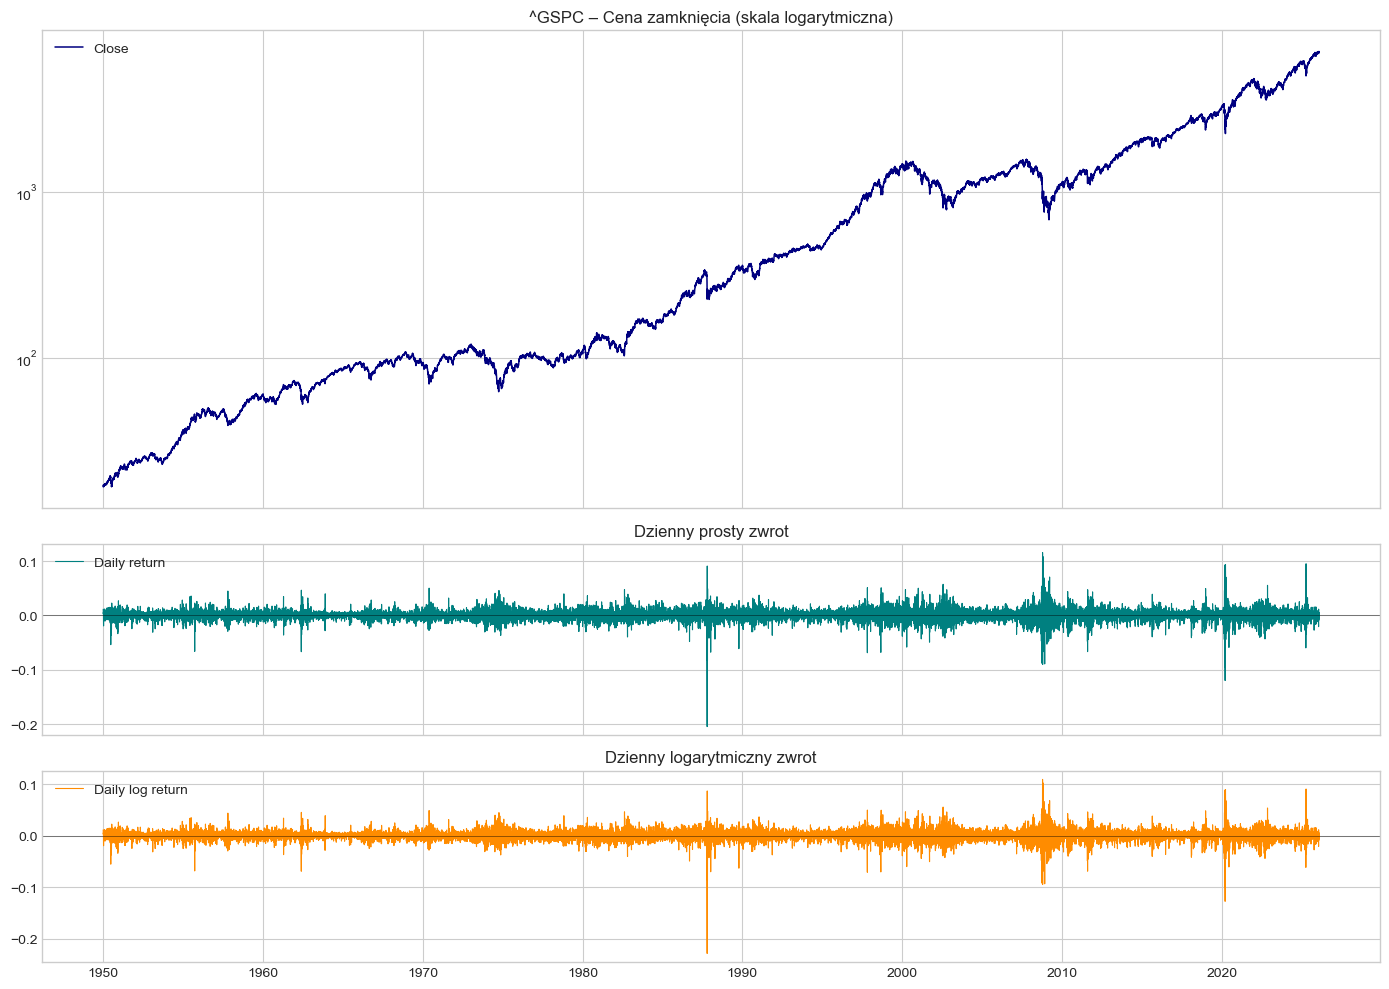

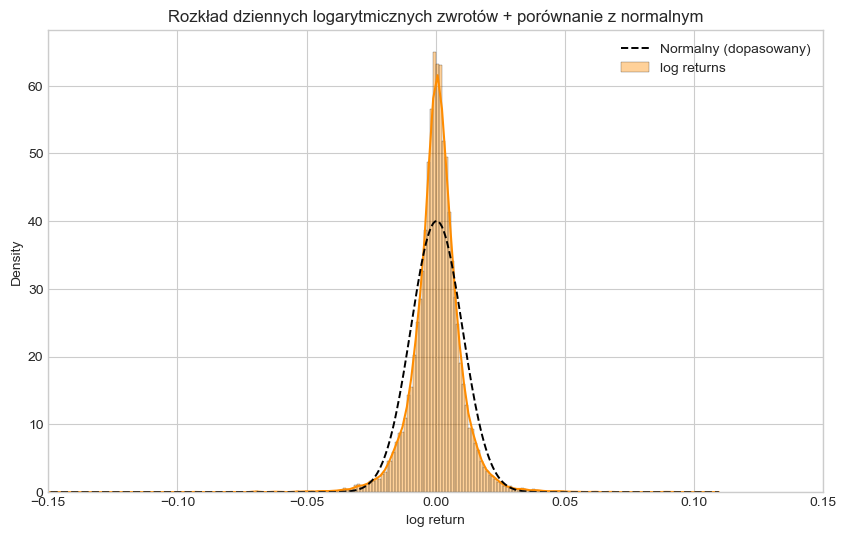

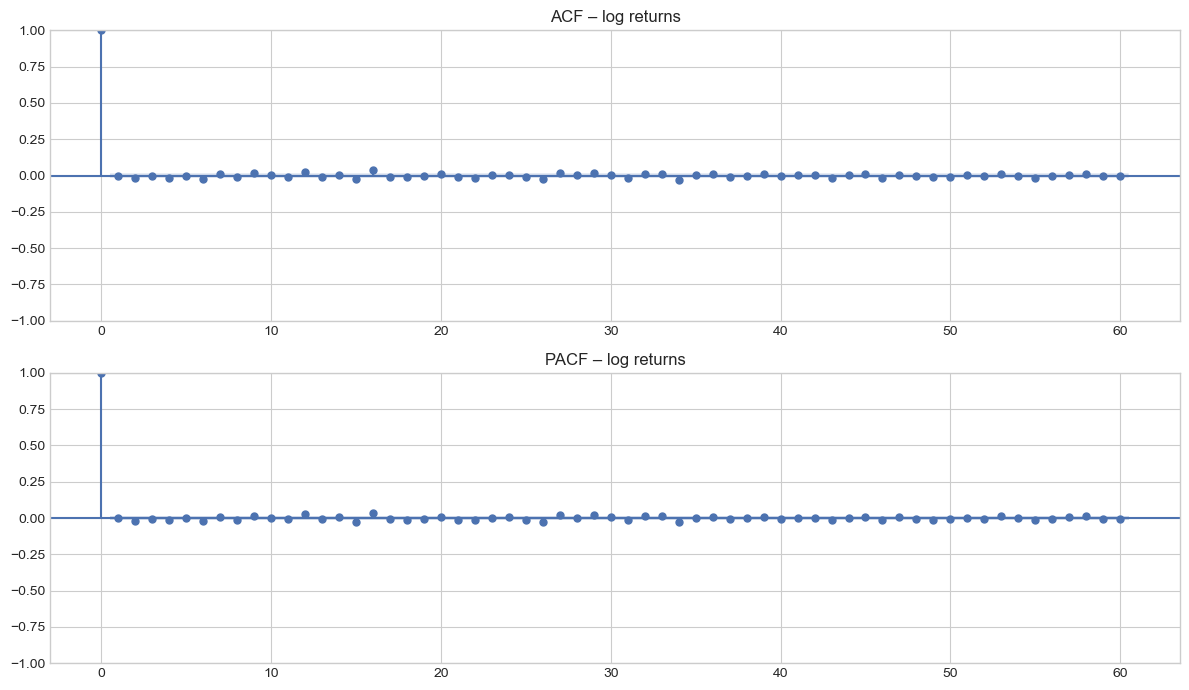

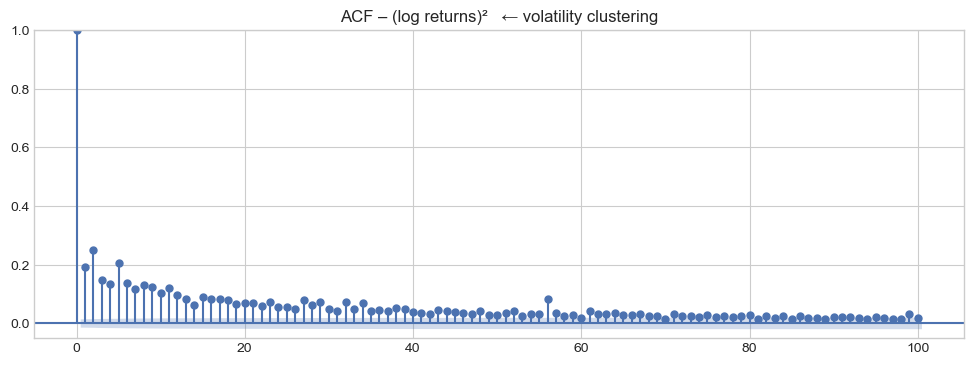


=== 15 największych dziennych spadków ===
Date
1987-10-19   -20.47
2020-03-16   -11.98
2020-03-12    -9.51
2008-10-15    -9.03
2008-12-01    -8.93
2008-09-29    -8.81
1987-10-26    -8.28
2008-10-09    -7.62
2020-03-09    -7.60
1997-10-27    -6.87
1998-08-31    -6.80
1988-01-08    -6.77
2008-11-20    -6.71
1962-05-28    -6.68
2011-08-08    -6.66
Name: return, dtype: float64

=== 15 największych dziennych wzrostów ===
Date
2008-10-13    11.58
2008-10-28    10.79
2025-04-09     9.52
2020-03-24     9.38
2020-03-13     9.29
1987-10-21     9.10
2009-03-23     7.08
2020-04-06     7.03
2008-11-13     6.92
2008-11-24     6.47
2009-03-10     6.37
2008-11-21     6.32
2020-03-26     6.24
2020-03-17     6.00
2002-07-24     5.73
Name: return, dtype: float64
[INFO] adj_close == close w całym zbiorze → pominięto w heatmapie


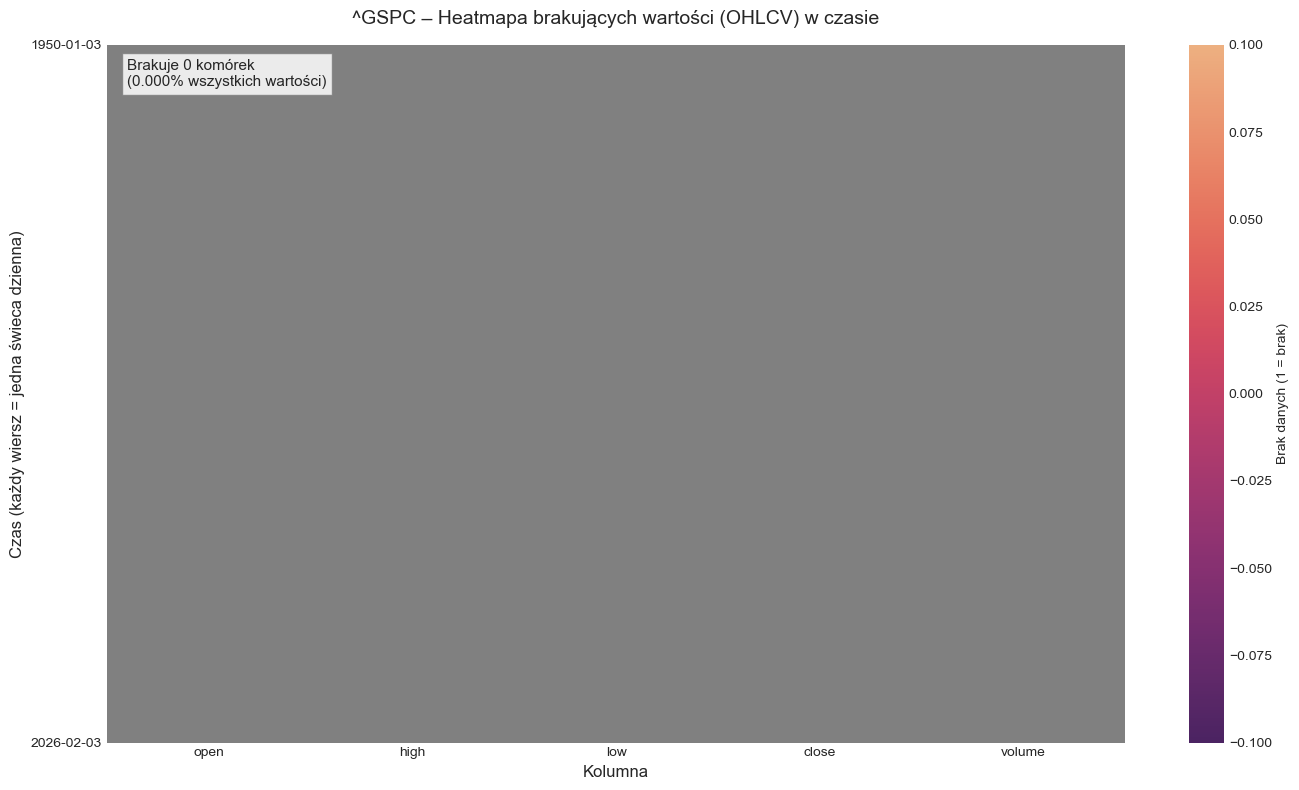


Liczba brakujących wartości w każdej kolumnie:
        Braki (szt.)  % brakujących
open               0            0.0
high               0            0.0
low                0            0.0
close              0            0.0
volume             0            0.0

BRAK BRAKÓW – dane są kompletne w całym zakresie.


In [10]:
# 3. EDA – S&P 500 daily data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
%matplotlib inline
# %config InlineBackend.figure_format = 'retina'   # jeśli używasz Jupyter

# =============================================================================
# Przygotowanie pomocniczych serii (już na etapie EDA – często robimy to tutaj)
# =============================================================================
df["return"]      = df["close"].pct_change()
df["log_return"]  = np.log(df["close"] / df["close"].shift(1))
df["range"]       = (df["high"] - df["low"]) / df["close"].shift(1)   # daily range %
df["body"]        = (df["close"] - df["open"]) / df["open"]
df["upper_wick"]  = (df["high"] - df[["open","close"]].max(axis=1)) / df["close"]
df["lower_wick"]  = (df[["open","close"]].min(axis=1) - df["low"]) / df["close"]

# =============================================================================
# 3.1 Podstawowe spojrzenie
# =============================================================================
print("\n=== Podstawowe informacje ===")
print(df.index.min().date(), "–", df.index.max().date())
print(f"Liczba rekordów: {len(df):,d}")
print(f"Średni dzienny zwrot: {df['return'].mean():.4%}")
print(f"Średni dzienny |log return|: {df['log_return'].abs().mean():.4%}")
print("\nStatystyki kluczowych kolumn:")
print(df[["open","high","low","close","volume","return","log_return"]].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).round(4))

# =============================================================================
# 3.2 Wizualizacja ceny i zwrotów
# =============================================================================
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1.2, 1.2]})

# Cena (log scale!)
axs[0].plot(df["close"], color="navy", lw=1.1, label="Close")
axs[0].set_yscale("log")
axs[0].set_title(f"{TICKER} – Cena zamknięcia (skala logarytmiczna)")
axs[0].legend(loc="upper left")

# Zwroty dzienne
axs[1].plot(df["return"], color="teal", lw=0.8, label="Daily return")
axs[1].axhline(0, color="black", lw=0.6, alpha=0.5)
axs[1].set_title("Dzienny prosty zwrot")
axs[1].legend(loc="upper left")

# Logarytmiczne zwroty (częściej używane w modelach)
axs[2].plot(df["log_return"], color="darkorange", lw=0.8, label="Daily log return")
axs[2].axhline(0, color="black", lw=0.6, alpha=0.5)
axs[2].set_title("Dzienny logarytmiczny zwrot")
axs[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

# =============================================================================
# 3.3 Rozkłady – porównanie normalnego + fat tails
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df["log_return"].dropna(), bins=300, kde=True, stat="density",
             color="darkorange", alpha=0.4, label="log returns")

# Dla porównania – normalny rozkład o takiej samej średniej i wariancji
x = np.linspace(df["log_return"].min(), df["log_return"].max(), 500)
normal_pdf = (1 / (df["log_return"].std() * np.sqrt(2*np.pi))) * \
             np.exp( - (x - df["log_return"].mean())**2 / (2 * df["log_return"].std()**2) )
ax.plot(x, normal_pdf, "k--", lw=1.4, label="Normalny (dopasowany)")

ax.set_title("Rozkład dziennych logarytmicznych zwrotów + porównanie z normalnym")
ax.set_xlabel("log return")
ax.set_xlim([-0.15, 0.15])   # zoom na centralną część – ogony widać dalej
ax.legend()
plt.show()

# =============================================================================
# 3.4 Autokorelacja zwrotów i kwadratów zwrotów (klucz do volatility clustering)
# =============================================================================
fig, axs = plt.subplots(2, 1, figsize=(12, 7))

plot_acf(df["log_return"].dropna(), lags=60, ax=axs[0], title="ACF – log returns")
plot_pacf(df["log_return"].dropna(), lags=60, ax=axs[1], title="PACF – log returns", method="ywm")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df["log_return"].dropna()**2, lags=100, ax=ax,
         title="ACF – (log returns)²   ← volatility clustering")
ax.set_ylim(bottom=-0.05)
plt.show()

# =============================================================================
# 3.5 Największe ruchy w historii (pomaga zrozumieć ekstremalne przypadki)
# =============================================================================
print("\n=== 15 największych dziennych spadków ===")
print(df["return"].nsmallest(15).round(4) * 100)

print("\n=== 15 największych dziennych wzrostów ===")
print(df["return"].nlargest(15).round(4) * 100)

# 3.6 Heatmapa braków w czasie – dla kolumn OHLC(V)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------------------------------------------
# Przygotowanie macierzy brakujących wartości (True = brak)
# --------------------------------------------------------------------
missing_matrix = df[["open", "high", "low", "close", "adj_close", "volume"]].isna()

# Jeśli adj_close jest identyczne z close → często yfinance to robi → możemy je pominąć w wizualizacji
if (df["close"] == df["adj_close"]).all():
    missing_matrix = missing_matrix.drop(columns=["adj_close"])
    print("[INFO] adj_close == close w całym zbiorze → pominięto w heatmapie")

# --------------------------------------------------------------------
# Heatmapa – pionowo czas, poziomo kolumny
# --------------------------------------------------------------------
plt.figure(figsize=(14, 8))

# Główna heatmapa
ax = sns.heatmap(
    missing_matrix,
    cmap="flare_r",           # czerwony = brak, jasny = obecne
    cbar_kws={'label': 'Brak danych (1 = brak)'},
    yticklabels=False,        # za dużo wierszy → etykiety y nieczytelne
    xticklabels=True,
    linewidths=0.01,
    linecolor='gray'
)

# Dodatkowe linie pionowe rozdzielające kolumny
ax.vlines(np.arange(0, missing_matrix.shape[1]+1), *ax.get_ylim(), color='gray', lw=0.8)

# Tytuł i podpisy
plt.title(f"{TICKER} – Heatmapa brakujących wartości (OHLCV) w czasie", fontsize=14, pad=15)
plt.xlabel("Kolumna", fontsize=12)
plt.ylabel("Czas (każdy wiersz = jedna świeca dzienna)", fontsize=12)

# Mały trik – pokazujemy zakres dat na osi Y (tylko początek i koniec)
n_rows = len(df)
plt.yticks([0, n_rows-1], [df.index[0].strftime("%Y-%m-%d"), df.index[-1].strftime("%Y-%m-%d")])

# Statystyka w rogu
total_cells = missing_matrix.size
missing_cells = missing_matrix.sum().sum()
missing_pct = missing_cells / total_cells * 100

plt.text(
    0.02, 0.98,
    f"Brakuje {missing_cells:,} komórek\n({missing_pct:.3f}% wszystkich wartości)",
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# Dodatkowe szybkie podsumowanie brakujących po kolumnach
# --------------------------------------------------------------------
print("\nLiczba brakujących wartości w każdej kolumnie:")
missing_counts = missing_matrix.sum()
missing_percent = missing_matrix.mean() * 100
summary = pd.DataFrame({
    "Braki (szt.)": missing_counts,
    "% brakujących": missing_percent.round(4)
}).sort_values("Braki (szt.)", ascending=False)

print(summary)

if missing_counts.sum() == 0:
    print("\nBRAK BRAKÓW – dane są kompletne w całym zakresie.")
elif missing_counts["volume"] > 0 and missing_counts[["open","high","low","close"]].sum().sum() == 0:
    print("\nTylko volume ma braki – typowe dla niektórych źródeł danych.")

In [4]:
# 4. Czyszczenie danych i ponowna walidacja

# brak danych do czyszczenia

In [11]:
# 5. Feature engineering

import numpy as np
import pandas as pd

EPS = 1e-12


def add_log_returns(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    eps: float = EPS,
    prefix: str = "lr",
) -> pd.DataFrame:
    out = df.copy()
    c = out[close_col].astype(float)
    out[f"{prefix}_1"] = np.log((c + eps) / (c.shift(1) + eps))
    return out


def add_candle_anatomy(
    df: pd.DataFrame,
    *,
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    eps: float = EPS,
    prefix: str = "candle",
) -> pd.DataFrame:
    out = df.copy()

    o = out[open_col].astype(float)
    h = out[high_col].astype(float)
    l = out[low_col].astype(float)
    c = out[close_col].astype(float)

    body = (c - o).abs()
    upper_wick = h - np.maximum(o, c)
    lower_wick = np.minimum(o, c) - l
    rng = (h - l).abs()

    denom = rng + eps

    out[f"{prefix}_body_norm_rng"] = body / denom
    out[f"{prefix}_upper_wick_norm_rng"] = upper_wick / denom
    out[f"{prefix}_lower_wick_norm_rng"] = lower_wick / denom
    out[f"{prefix}_direction"] = np.sign(c - o)

    return out


def _true_range(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    prev_close = close.shift(1)
    tr = pd.concat(
        [
            (high - low).abs(),
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    return tr


def add_volatility_features(
    df: pd.DataFrame,
    *,
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    atr_window: int = 14,
    ret_std_window: int = 20,
    logret_col: str = "lr_1",
    prefix: str = "vol",
) -> pd.DataFrame:
    out = df.copy()

    h = out[high_col].astype(float)
    l = out[low_col].astype(float)
    c = out[close_col].astype(float)

    tr = _true_range(h, l, c)
    atr = tr.rolling(atr_window, min_periods=atr_window).mean()
    out[f"{prefix}_atr_{atr_window}"] = atr

    if logret_col in out.columns:
        out[f"{prefix}_ret_std_{ret_std_window}"] = out[logret_col].rolling(
            ret_std_window, min_periods=ret_std_window
        ).std()
    else:
        out[f"{prefix}_ret_std_{ret_std_window}"] = np.nan

    return out


def add_volume_features(
    df: pd.DataFrame,
    *,
    volume_col: str = "volume",
    volume_window: int = 50,
    eps: float = EPS,
    prefix: str = "volm",
) -> pd.DataFrame:
    out = df.copy()
    v = out[volume_col].astype(float)

    v_mean = v.rolling(volume_window, min_periods=volume_window).mean()
    rel_v = v / (v_mean + eps)

    out[f"{prefix}_rel"] = rel_v
    out[f"{prefix}_log1p_rel"] = np.log1p(rel_v.clip(lower=0))

    return out


def add_features_v0_1(
    df: pd.DataFrame,
    *,
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    volume_col: str = "volume",
    atr_window: int = 14,
    ret_std_window: int = 20,
    volume_window: int = 50,
) -> pd.DataFrame:
    required = {open_col, high_col, low_col, close_col, volume_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Brakuje kolumn w df: {missing}")

    out = df.copy()

    out = add_log_returns(out, close_col=close_col, prefix="lr")

    out = add_candle_anatomy(
        out,
        open_col=open_col,
        high_col=high_col,
        low_col=low_col,
        close_col=close_col,
        prefix="candle",
    )

    out = add_volatility_features(
        out,
        high_col=high_col,
        low_col=low_col,
        close_col=close_col,
        atr_window=atr_window,
        ret_std_window=ret_std_window,
        logret_col="lr_1",
        prefix="vol",
    )

    out = add_volume_features(
        out,
        volume_col=volume_col,
        volume_window=volume_window,
        prefix="volm",
    )

    return out



In [12]:
df_feat = add_features_v0_1(df)  # df musi mieć: open, high, low, close, volume

In [13]:
# 6. Ponowna walidacja danych
# ──────────────────────────────────────────────────────────────────────────────
# Ten punkt zawiera:
# - twarde testy bezpieczeństwa (NO-FUTURE-LEAKAGE)
# - miękkie testy jakości / stabilności pipeline'u (PIPELINE-INVARIANCE)
#
# Zasady:
# - no_future_leakage → BŁĄD KRYTYCZNY (pipeline STOP)
# - pipeline_invariance → OSTRZEŻENIE (informacyjne)
# ──────────────────────────────────────────────────────────────────────────────

import os
import pandas as pd
import numpy as np


# ──────────────────────────────────────────────────────────────────────────────
# Pomocnicze utils
# ──────────────────────────────────────────────────────────────────────────────

def _ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def _build_black_sheep_df(
    out: pd.DataFrame,
    idx: pd.Index,
    *,
    test_name: str,
    reason: str,
    ohlcv_cols: list[str],
    feature_cols: list[str],
) -> pd.DataFrame:
    """
    Zwraca DataFrame z rekordami odpowiedzialnymi za fail + metadane.
    """
    if len(idx) == 0:
        return pd.DataFrame()

    cols_keep = [c for c in (ohlcv_cols + ["adj_close"]) if c in out.columns]
    cols_keep += [c for c in feature_cols if c in out.columns]
    cols_keep = list(dict.fromkeys(cols_keep))  # zachowaj kolejność, usuń duplikaty

    df_bad = out.loc[idx, cols_keep].copy()
    df_bad.insert(0, "test_name", test_name)
    df_bad.insert(1, "reason", reason)
    df_bad.insert(2, "row_index", df_bad.index)
    return df_bad


# ──────────────────────────────────────────────────────────────────────────────
# Główna walidacja
# ──────────────────────────────────────────────────────────────────────────────

def validate_features_with_black_sheep(
    df_feat: pd.DataFrame,
    *,
    df_raw: pd.DataFrame | None = None,
    feature_cols: list[str] | None = None,
    ohlcv_cols: list[str] = ["open", "high", "low", "close", "volume"],
    eps: float = 1e-12,
    max_nan_pct: float = 0.01,
    allow_inf: bool = False,
    leakage_n_samples: int = 50,
    leakage_start_row: int = 100,
    export_dir: str = "data/market",
    export_filename: str = "validation_black_sheep.csv",
) -> dict:
    """
    Walidacja po feature engineering + zbieranie „czarnych owiec” per blok testów.

    Testy:
    - NaN / Inf
    - Sanity checks cech
    - no_future_leakage      (CRITICAL)
    - pipeline_invariance   (WARNING)

    Wymaga:
    - add_features_v0_1(df) dostępnej w scope
    """

    out = df_feat.copy()
    issues: list[str] = []
    warnings: list[str] = []
    stats: dict = {}

    if feature_cols is None:
        feature_cols = [c for c in out.columns if c not in ohlcv_cols + ["adj_close"]]

    black_sheep: dict[str, pd.DataFrame] = {}

    # ─────────────────────────────
    # 1) NaN check
    # ─────────────────────────────
    nan_mask = out[feature_cols].isna()
    nan_counts = nan_mask.sum()
    nan_pct = nan_counts / len(out)
    stats["nan_pct_per_feature"] = nan_pct.to_dict()

    high_nan = nan_pct[nan_pct > max_nan_pct]
    if not high_nan.empty:
        idx_bad = out.index[nan_mask[high_nan.index].any(axis=1)]
        issues.append(
            f"Za dużo NaN w cechach: {high_nan.to_dict()} (próg: {max_nan_pct*100}%)"
        )
        black_sheep["nan_check"] = _build_black_sheep_df(
            out,
            idx_bad,
            test_name="nan_check",
            reason="Nadmierna liczba NaN po feature engineering",
            ohlcv_cols=ohlcv_cols,
            feature_cols=feature_cols,
        )

    # ─────────────────────────────
    # 2) Inf check
    # ─────────────────────────────
    inf_mask = np.isinf(out[feature_cols])
    inf_mask_df = pd.DataFrame(inf_mask, index=out.index, columns=feature_cols)
    inf_counts = inf_mask_df.sum()

    if not allow_inf and inf_counts.sum() > 0:
        bad_features = inf_counts[inf_counts > 0].to_dict()
        idx_bad = out.index[inf_mask_df.any(axis=1)]
        issues.append(f"Wykryto wartości inf w cechach: {bad_features}")
        black_sheep["inf_check"] = _build_black_sheep_df(
            out,
            idx_bad,
            test_name="inf_check",
            reason="Wartości inf po feature engineering",
            ohlcv_cols=ohlcv_cols,
            feature_cols=feature_cols,
        )

    # ─────────────────────────────
    # 3) Sanity checks specyficzne dla cech
    # ─────────────────────────────
    sanity_bad_idx = []

    candle_cols = [
        "candle_body_norm_rng",
        "candle_upper_wick_norm_rng",
        "candle_lower_wick_norm_rng",
    ]

    if all(c in out.columns for c in candle_cols):
        candle_parts = out[candle_cols]
        out_of_range = (candle_parts < -eps).any(axis=1) | (candle_parts > 1 + eps).any(axis=1)
        sums = candle_parts.sum(axis=1)
        bad_sum = ~np.isclose(sums, 1.0, atol=eps)

        idx_bad = out.index[out_of_range | bad_sum]
        if len(idx_bad) > 0:
            sanity_bad_idx.append(idx_bad)
            issues.append("Nieprawidłowe znormalizowane części świecy")

    if "candle_direction" in out.columns:
        invalid_dir = ~out["candle_direction"].isin([-1, 0, 1])
        idx_bad = out.index[invalid_dir]
        if len(idx_bad) > 0:
            sanity_bad_idx.append(idx_bad)
            issues.append("Nieprawidłowe wartości candle_direction")

    for col_name, msg in [
        ("vol_atr_14", "Negatywne wartości ATR"),
        ("volm_rel", "Negatywne wartości relative volume"),
    ]:
        if col_name in out.columns:
            bad = out[col_name] < -eps
            idx_bad = out.index[bad]
            if len(idx_bad) > 0:
                sanity_bad_idx.append(idx_bad)
                issues.append(msg)

    if sanity_bad_idx:
        idx_union = sanity_bad_idx[0].union_many(sanity_bad_idx[1:]) if len(sanity_bad_idx) > 1 else sanity_bad_idx[0]
        black_sheep["sanity_feature_checks"] = _build_black_sheep_df(
            out,
            idx_union,
            test_name="sanity_feature_checks",
            reason="Cechy łamią podstawowe założenia logiczne",
            ohlcv_cols=ohlcv_cols,
            feature_cols=feature_cols,
        )

    # ─────────────────────────────
    # 4a) NO-FUTURE-LEAKAGE (CRITICAL)
    # ─────────────────────────────
    if df_raw is not None:
        fail = False
        records = []

        if len(df_raw) > leakage_start_row + 5:
            population = np.arange(leakage_start_row, len(df_raw))
            n_samples = min(leakage_n_samples, max(1, len(population) // 10))
            replace = n_samples > len(population)

            for i in np.random.choice(population, n_samples, replace=replace):
                try:
                    prefix_feats = add_features_v0_1(df_raw.iloc[:i]).iloc[-1:][feature_cols]
                    full_feats = df_feat.iloc[i-1:i][feature_cols]
                except Exception as e:
                    issues.append(f"no_future_leakage: błąd przeliczania cech ({repr(e)})")
                    fail = True
                    records.append(df_feat.index[i-1])
                    break

                if not np.allclose(
                    full_feats.values,
                    prefix_feats.values,
                    atol=1e-6,
                    equal_nan=True,
                ):
                    issues.append(f"no_future_leakage: cecha zależy od przyszłości (wiersz {i})")
                    fail = True
                    records.append(df_feat.index[i-1])
                    break

        if fail and records:
            black_sheep["no_future_leakage"] = _build_black_sheep_df(
                df_feat,
                pd.Index(records),
                test_name="no_future_leakage",
                reason="Cecha wykorzystuje informację niedostępną w chwili t",
                ohlcv_cols=ohlcv_cols,
                feature_cols=feature_cols,
            )

    # ─────────────────────────────
    # 4b) PIPELINE-INVARIANCE (WARNING)
    # ─────────────────────────────
    pipeline_sensitive = False
    pipeline_records = []

    if len(df_feat) > leakage_start_row + 5:
        population = np.arange(leakage_start_row, len(df_feat))
        n_samples = min(leakage_n_samples, max(1, len(population) // 10))
        replace = n_samples > len(population)

        for i in np.random.choice(population, n_samples, replace=replace):
            try:
                prefix_feats = add_features_v0_1(df_feat.iloc[:i]).iloc[-1:][feature_cols]
                full_feats = df_feat.iloc[i-1:i][feature_cols]
            except Exception as e:
                warnings.append(f"pipeline_invariance: błąd przeliczania cech ({repr(e)})")
                pipeline_sensitive = True
                pipeline_records.append(df_feat.index[i-1])
                break

            if not np.allclose(
                full_feats.values,
                prefix_feats.values,
                atol=1e-6,
                equal_nan=True,
            ):
                warnings.append(
                    f"pipeline_invariance: cechy wrażliwe na usunięte rekordy (wiersz {i})"
                )
                pipeline_sensitive = True
                pipeline_records.append(df_feat.index[i-1])
                break

    if pipeline_sensitive and pipeline_records:
        black_sheep["pipeline_invariance"] = _build_black_sheep_df(
            df_feat,
            pd.Index(pipeline_records),
            test_name="pipeline_invariance",
            reason="Cecha zależna od wcześniejszych filtrów / długości historii",
            ohlcv_cols=ohlcv_cols,
            feature_cols=feature_cols,
        )

    # ─────────────────────────────
    # Eksport CSV
    # ─────────────────────────────
    _ensure_dir(export_dir)

    if black_sheep:
        df_black = pd.concat(black_sheep.values(), ignore_index=True)
        export_path = os.path.join(export_dir, export_filename)
        df_black.to_csv(export_path, index=False)
        stats["black_sheep_csv_path"] = export_path
        stats["black_sheep_counts"] = {k: len(v) for k, v in black_sheep.items()}

    # ─────────────────────────────
    # Status końcowy
    # ─────────────────────────────
    is_valid = len(issues) == 0
    stats["n_features"] = len(feature_cols)
    stats["feature_cols"] = feature_cols

    return {
        "is_valid": is_valid,
        "critical_issues": issues,
        "warnings": warnings,
        "stats": stats,
        "black_sheep": black_sheep,
    }


# ──────────────────────────────────────────────────────────────────────────────
# UŻYCIE
# ──────────────────────────────────────────────────────────────────────────────

validation_feat_report = validate_features_with_black_sheep(
    df_feat=df_feat,
    df_raw=df,  # ← wymagane dla no_future_leakage
    export_dir="data/market",
    export_filename="validation_black_sheep.csv",
)

print("\n" + "=" * 80)
print("RAPORT PONOWNEJ WALIDACJI PO FEATURE ENGINEERING")
print("=" * 80)
print(f"Status ogólny: {'OK' if validation_feat_report['is_valid'] else 'NIE PRZEZ WALIDACJĘ'}")
print()

if validation_feat_report["critical_issues"]:
    print("Błędy krytyczne:")
    for issue in validation_feat_report["critical_issues"]:
        print(f"✗ {issue}")
    print()

if validation_feat_report["warnings"]:
    print("Ostrzeżenia:")
    for warn in validation_feat_report["warnings"]:
        print(f"! {warn}")
    print()

print("Statystyki:")
for k, v in validation_feat_report["stats"].items():
    print(f" {k:22} : {v}")

if not validation_feat_report["is_valid"]:
    raise RuntimeError(
        "Ponowna walidacja cech nie przeszła – wykryto krytyczne naruszenia (no_future_leakage)."
    )



RAPORT PONOWNEJ WALIDACJI PO FEATURE ENGINEERING
Status ogólny: NIE PRZEZ WALIDACJĘ

Błędy krytyczne:
✗ Nieprawidłowe znormalizowane części świecy

Statystyki:
 nan_pct_per_feature    : {'return': 5.224114512590116e-05, 'log_return': 5.224114512590116e-05, 'range': 5.224114512590116e-05, 'body': 0.0, 'upper_wick': 0.0, 'lower_wick': 0.0, 'lr_1': 5.224114512590116e-05, 'candle_body_norm_rng': 0.0, 'candle_upper_wick_norm_rng': 0.0, 'candle_lower_wick_norm_rng': 0.0, 'candle_direction': 0.0, 'vol_atr_14': 0.0006791348866367151, 'vol_ret_std_20': 0.0010448229025180231, 'volm_rel': 0.0025598161111691567, 'volm_log1p_rel': 0.0025598161111691567}
 black_sheep_csv_path   : data/market/validation_black_sheep.csv
 black_sheep_counts     : {'sanity_feature_checks': 3051}
 n_features             : 15
 feature_cols           : ['return', 'log_return', 'range', 'body', 'upper_wick', 'lower_wick', 'lr_1', 'candle_body_norm_rng', 'candle_upper_wick_norm_rng', 'candle_lower_wick_norm_rng', 'candle_di

RuntimeError: Ponowna walidacja cech nie przeszła – wykryto krytyczne naruszenia (no_future_leakage).

In [16]:
# 6a. Ponowne czyszczenie danych

from pathlib import Path
import pandas as pd


def drop_rows_by_dates_from_csv(
    df_feat: pd.DataFrame,
    *,
    csv_path: str | Path,
    date_col: str,
    df_date_col: str | None = None,
) -> pd.DataFrame:
    """
    Usuwa rekordy z df_feat na podstawie listy dat zapisanych w pliku CSV.

    Parametry
    ----------
    df_feat : pd.DataFrame
        DataFrame z cechami (indeks DatetimeIndex lub kolumna z datą).

    csv_path : str | Path
        Ścieżka do pliku CSV zawierającego daty rekordów do usunięcia.

    date_col : str
        Nazwa kolumny w CSV zawierającej daty do usunięcia.

    df_date_col : str | None
        Jeśli None → używany jest DatetimeIndex df_feat.
        Jeśli podano → nazwa kolumny w df_feat zawierającej daty.

    Zwraca
    -------
    pd.DataFrame
        Nowy DataFrame z usuniętymi rekordami.

    Wyjątki
    --------
    FileNotFoundError
        Gdy plik CSV nie istnieje.

    ValueError
        Gdy CSV jest pusty, brak kolumny z datą,
        brak parsowalnych dat lub df_feat nie ma dat.
    """

    # ─────────────────────────────
    # 1) Walidacja pliku CSV
    # ─────────────────────────────
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"Plik CSV nie istnieje: {csv_path}")

    df_dates = pd.read_csv(csv_path)

    if df_dates.empty:
        raise ValueError(f"Plik CSV jest pusty: {csv_path}")

    if date_col not in df_dates.columns:
        raise ValueError(
            f"Brak kolumny '{date_col}' w CSV. "
            f"Dostępne kolumny: {list(df_dates.columns)}"
        )

    # ─────────────────────────────
    # 2) Parsowanie dat z CSV
    # ─────────────────────────────
    dates_raw = df_dates[date_col]

    dates = pd.to_datetime(dates_raw, errors="coerce")

    if dates.isna().all():
        raise ValueError(
            f"Nie udało się sparsować żadnej daty z kolumny '{date_col}' w CSV"
        )

    dates = dates.dropna().unique()

    # ─────────────────────────────
    # 3) Pobranie dat z df_feat
    # ─────────────────────────────
    df = df_feat.copy()

    if df_date_col is None:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(
                "df_feat nie ma DatetimeIndex, a df_date_col=None. "
                "Podaj nazwę kolumny z datą w df_feat."
            )
        df_dates_feat = df.index
    else:
        if df_date_col not in df.columns:
            raise ValueError(
                f"Brak kolumny '{df_date_col}' w df_feat. "
                f"Dostępne kolumny: {list(df.columns)}"
            )
        df_dates_feat = pd.to_datetime(df[df_date_col], errors="coerce")

        if df_dates_feat.isna().all():
            raise ValueError(
                f"Kolumna '{df_date_col}' w df_feat nie zawiera parsowalnych dat"
            )

    # ─────────────────────────────
    # 4) Usuwanie rekordów
    # ─────────────────────────────
    mask_to_drop = df_dates_feat.isin(dates)

    n_drop = int(mask_to_drop.sum())

    if n_drop == 0:
        raise ValueError(
            "Nie znaleziono żadnych rekordów w df_feat "
            "odpowiadających datom z CSV"
        )

    df_clean = df.loc[~mask_to_drop].copy()

    print(
        f"[INFO] Usunięto {n_drop} rekordów na podstawie dat z pliku CSV "
        f"({csv_path})"
    )

    return df_clean


In [17]:
df_feat = drop_rows_by_dates_from_csv(
    df_feat,
    csv_path="data/market/validation_black_sheep.csv",
    date_col="row_index",
)

[INFO] Usunięto 2 rekordów na podstawie dat z pliku CSV (data/market/validation_black_sheep.csv)


In [18]:
# Ponowna walidacja

validation_feat_report = validate_features_with_black_sheep(
    df_feat=df_feat,
    df_raw=df,  # ← wymagane dla no_future_leakage
    export_dir="data/market",
    export_filename="validation_black_sheep.csv",
)

print("\n" + "=" * 80)
print("RAPORT PONOWNEJ WALIDACJI PO FEATURE ENGINEERING")
print("=" * 80)
print(f"Status ogólny: {'OK' if validation_feat_report['is_valid'] else 'NIE PRZEZ WALIDACJĘ'}")
print()

if validation_feat_report["critical_issues"]:
    print("Błędy krytyczne:")
    for issue in validation_feat_report["critical_issues"]:
        print(f"✗ {issue}")
    print()

if validation_feat_report["warnings"]:
    print("Ostrzeżenia:")
    for warn in validation_feat_report["warnings"]:
        print(f"! {warn}")
    print()

print("Statystyki:")
for k, v in validation_feat_report["stats"].items():
    print(f" {k:22} : {v}")

if not validation_feat_report["is_valid"]:
    raise RuntimeError(
        "Ponowna walidacja cech nie przeszła – wykryto krytyczne naruszenia (no_future_leakage)."
    )


RAPORT PONOWNEJ WALIDACJI PO FEATURE ENGINEERING
Status ogólny: NIE PRZEZ WALIDACJĘ

Błędy krytyczne:
✗ no_future_leakage: cecha zależy od przyszłości (wiersz 1145)

Ostrzeżenia:
! pipeline_invariance: cechy wrażliwe na usunięte rekordy (wiersz 3175)

Statystyki:
 nan_pct_per_feature    : {'return': 0.0, 'log_return': 0.0, 'range': 0.0, 'body': 0.0, 'upper_wick': 0.0, 'lower_wick': 0.0, 'lr_1': 0.0, 'candle_body_norm_rng': 0.0, 'candle_upper_wick_norm_rng': 0.0, 'candle_lower_wick_norm_rng': 0.0, 'candle_direction': 0.0, 'vol_atr_14': 0.0, 'vol_ret_std_20': 0.0, 'volm_rel': 0.0, 'volm_log1p_rel': 0.0}
 black_sheep_csv_path   : data/market/validation_black_sheep.csv
 black_sheep_counts     : {'no_future_leakage': 1, 'pipeline_invariance': 1}
 n_features             : 15
 feature_cols           : ['return', 'log_return', 'range', 'body', 'upper_wick', 'lower_wick', 'lr_1', 'candle_body_norm_rng', 'candle_upper_wick_norm_rng', 'candle_lower_wick_norm_rng', 'candle_direction', 'vol_atr_14

RuntimeError: Ponowna walidacja cech nie przeszła – wykryto krytyczne naruszenia (no_future_leakage).

In [12]:
import numpy as np
import pandas as pd

def leakage_diff_report(
    df_feat: pd.DataFrame,
    *,
    row_i: int,
    feature_cols: list[str],
    recompute_fn,
    atol: float = 1e-6,
    rtol: float = 1e-6,
) -> pd.DataFrame:
    if row_i <= 1 or row_i > len(df_feat):
        raise ValueError(f"row_i={row_i} poza zakresem 1..{len(df_feat)}")

    full_row = df_feat.iloc[row_i-1:row_i][feature_cols].astype(float)
    prefix_df = df_feat.iloc[:row_i].copy()

    prefix_row = recompute_fn(prefix_df).iloc[-1:][feature_cols].astype(float)

    diffs = (full_row.iloc[0] - prefix_row.iloc[0]).abs()
    rel = diffs / (prefix_row.iloc[0].abs() + 1e-12)

    out = pd.DataFrame({
        "full": full_row.iloc[0],
        "prefix": prefix_row.iloc[0],
        "abs_diff": diffs,
        "rel_diff": rel
    })

    # pokaż tylko istotne różnice wg allclose
    mask = ~np.isclose(out["full"].values, out["prefix"].values, atol=atol, rtol=rtol, equal_nan=True)
    out = out.loc[mask].sort_values("abs_diff", ascending=False)

    return out


In [13]:
feature_cols = [c for c in df_feat.columns if c not in ["open","high","low","close","volume","adj_close"]]
report = leakage_diff_report(df_feat, row_i=1387, feature_cols=feature_cols, recompute_fn=add_features_v0_1)
print(report.head(20))


                    full    prefix  abs_diff  rel_diff
volm_rel        1.086155  1.060497  0.025658  0.024194
volm_log1p_rel  0.735323  0.722947  0.012375  0.017118
vol_ret_std_20  0.003484  0.005557  0.002073  0.373117
